In [1]:
from google.colab import files
files.upload()

Saving animals.jpg to animals.jpg


{'animals.jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00`\x00`\x00\x00\xff\xdb\x00C\x00\n\x07\x07\t\x07\x06\n\t\x08\t\x0b\x0b\n\x0c\x0f\x19\x10\x0f\x0e\x0e\x0f\x1e\x16\x17\x12\x19$ &%# #"(-90(*6+"#2D26;=@@@&0FKE>J9?@=\xff\xdb\x00C\x01\x0b\x0b\x0b\x0f\r\x0f\x1d\x10\x10\x1d=)#)==================================================\xff\xc0\x00\x11\x08\x00\xb4\x01A\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\xc7\xc8\xc9\xca\xd2\xd3\xd4\xd5\xd6\xd7\xd8\xd9\xda

Running on: cpu


Saving animals.jpg to animals (2).jpg
Using image: /content/animals (2).jpg


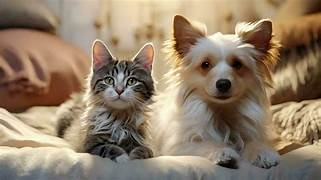


image 1/1 /content/animals (2).jpg: 480x832 1 cat, 1 dog, 693.3ms
Speed: 19.1ms preprocess, 693.3ms inference, 5.6ms postprocess per image at shape (1, 3, 480, 832)


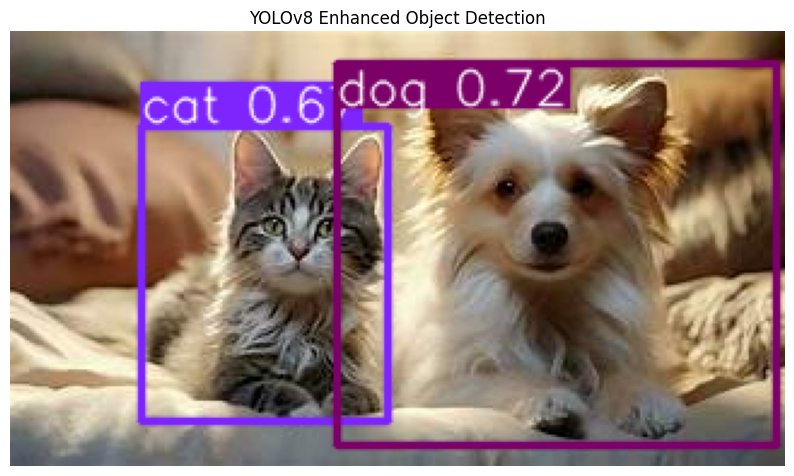


--- Detection Summary ---
Inference Time: 693.35 ms
Objects Found: 2

1) DOG | Confidence: 0.72
   Box: (135, 13) → (317, 171)

2) CAT | Confidence: 0.67
   Box: (54, 39) → (156, 161)



In [4]:
# --- 1. Install Required Libraries ---
!pip install ultralytics opencv-python matplotlib

# --- 2. Imports ---
import torch
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
from google.colab import files

# --- 3. Device Check ---
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on:", device)

# --- 4. Upload Image ---
uploaded = files.upload()

# Automatically get uploaded file name
img_name = list(uploaded.keys())[0]
img_path = "/content/" + img_name

print("Using image:", img_path)

# --- 5. Preview Image ---
display(Image.open(img_path))

# --- 6. Load Improved YOLO Model (BETTER THAN NANO) ---
detector = YOLO("yolov8s.pt")   # 🔥 better accuracy

# --- 7. Perform Detection (IMPROVED SETTINGS) ---
results = detector.predict(
    source=img_path,
    conf=0.2,        # 🔥 lower threshold (detect more objects)
    imgsz=832,       # 🔥 better for small objects
    device=device
)

# Extract first result
res = results[0]

# --- 8. Visualization ---
output_img = res.plot()
output_img = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,6))
plt.imshow(output_img)
plt.axis("off")
plt.title("YOLOv8 Enhanced Object Detection")
plt.show()

# --- 9. Detection Details ---
print("\n--- Detection Summary ---")
print(f"Inference Time: {res.speed['inference']:.2f} ms")
print(f"Objects Found: {len(res.boxes)}\n")

# --- 10. Debug + Output ---
for i, box in enumerate(res.boxes, start=1):
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    label = detector.names[cls_id]

    x1, y1, x2, y2 = map(int, box.xyxy[0])

    print(f"{i}) {label.upper()} | Confidence: {conf:.2f}")
    print(f"   Box: ({x1}, {y1}) → ({x2}, {y2})\n")